# Visualise latent positions recovery

In [1]:
import sys
import os
import pandas as pd

# Add the parent directory (simcode) to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.dgp import GaussianNetwork
from src.metrics import Rejection, FalseRejection, rv_coefficient
from src.methods import RVPermutationTest
from src.simulation_functions import run_simulation
from src.analyse_functions import aggregate_results
import re
from src.plot_functions import plot_grid, plot_with_bands
import ast
import numpy as np

# Latent position recovery

### Different copulas

In [3]:
results = pd.read_csv("simulation_results_20260212_1158.csv")

In [4]:
results["rho"] = results["args"].apply(
    lambda x: re.search(r"'rho':\s*(\d+\.?\d*)", x).group(1)
)

results["ComputeAll"] = results["ComputeAll"].apply(
    lambda x: ast.literal_eval(re.sub(r"np\.float64\(([^)]+)\)", r"\1", x))
)

results['RelativeFrobeniusNorm_x'] = results['ComputeAll'].apply(lambda x: x.get('RelativeFrobeniusNorm_x', np.nan))
results['RelativeFrobeniusNorm_z'] = results['ComputeAll'].apply(lambda x: x.get('RelativeFrobeniusNorm_z', np.nan))

results['FalseRejection'] = results['ComputeAll'].apply(lambda x: x.get('FalseRejection', np.nan))
results['TrueRejection'] = results['ComputeAll'].apply(lambda x: x.get('TrueRejection', np.nan))

results['dgp_name'] = results['dgp'].apply(lambda x: x.split('_')[0])
results['copula_type'] = results['dgp'].apply(lambda x: x.split('_')[1])

In [5]:
results_null = results[results['rho'] == '0'].copy()
results_alt = results[results['rho'] != '0'].copy()
results_alt_05 = results[results['rho'] == '0.5'].copy()
results_alt_01 = results[results['rho'] == '0.1'].copy()
results_alt_02 = results[results['rho'] == '0.2'].copy()

In [6]:
# neat thing: NaN are ignored
agg_null = aggregate_results(results_null, 
                             y_axis="RelativeFrobeniusNorm_x",
                             x_axis="n",
                             factors=["edge_var", "dgp_name", "copula_type"])

agg_alt = aggregate_results(results_alt, 
                            y_axis="RelativeFrobeniusNorm_x",
                            x_axis="n",
                            factors=["rho", "dgp_name", "copula_type"])

agg_alt_05 = aggregate_results(results_alt_05, 
                               y_axis="RelativeFrobeniusNorm_x",
                               x_axis="n",
                               factors=["edge_var", "dgp_name", "copula_type"])

agg_alt_01 = aggregate_results(results_alt_01, 
                               y_axis="RelativeFrobeniusNorm_x",
                               x_axis="n",
                               factors=["edge_var", "dgp_name", "copula_type"])

agg_alt_02 = aggregate_results(results_alt_02, 
                               y_axis="RelativeFrobeniusNorm_x",
                               x_axis="n",
                               factors=["edge_var", "dgp_name", "copula_type"])

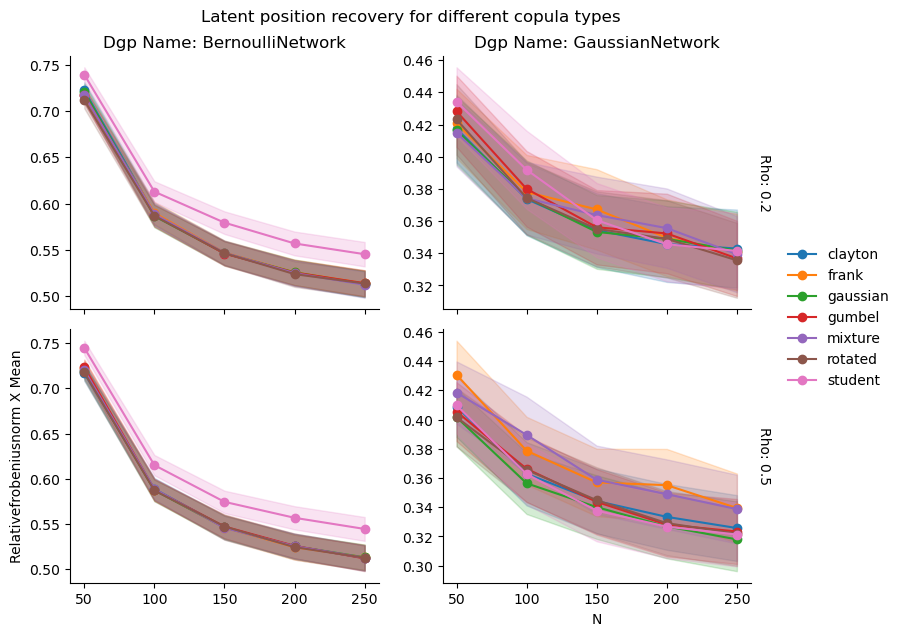

In [7]:
plot_grid(
    grouped_stats=agg_alt,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="RelativeFrobeniusNorm_x_mean",
    factors=["copula_type", "dgp_name", "rho"],
    height=3,
    se_bands="RelativeFrobeniusNorm_x_sem",
    share_x=True,
    share_y=False,
    title="Latent position recovery for different copula types",
)

### Different marginals

In [8]:
# Simulations setup 

# nsim = 100
# n = [50, 100, 150, 200, 250]
# k = [3]
# rho = [0]
# alpha = [0.05]
# marginals = ["gaussian", "uniform", "exponential", "t 5", "chi2 5", "beta 2 5"]
# edge_var = [1]
# method = [
#     FitIndependent
# ]

# npermutations = [100]
# metrics = [ComputeAll()]
# approximation = ["F-distr"]

# setup = [
#     (partial(GaussianNetwork, copula_model='gaussian'), MLE_gaussian),
#     (partial(BernoulliNetwork, copula_model='gaussian'), MLE_logistic),
# ]

In [9]:
results = pd.read_csv("simulation_results_20260215_0859.csv")

In [10]:
results["rho"] = results["args"].apply(
    lambda x: re.search(r"'rho':\s*(\d+\.?\d*)", x).group(1)
)

results["ComputeAll"] = results["ComputeAll"].apply(
    lambda x: ast.literal_eval(re.sub(r"np\.float64\(([^)]+)\)", r"\1", x))
)

results['RelativeFrobeniusNorm_x'] = results['ComputeAll'].apply(lambda x: x.get('RelativeFrobeniusNorm_x', np.nan))
results['RelativeFrobeniusNorm_z'] = results['ComputeAll'].apply(lambda x: x.get('RelativeFrobeniusNorm_z', np.nan))

results['FalseRejection'] = results['ComputeAll'].apply(lambda x: x.get('FalseRejection', np.nan))
results['TrueRejection'] = results['ComputeAll'].apply(lambda x: x.get('TrueRejection', np.nan))

results['dgp_name'] = results['dgp'].apply(lambda x: x.split('_')[0])
results['marginals'] = results['args'].apply(lambda x: re.search(r"'marginals':\s*['\"]([^'\"]+)['\"]", x).group(1))

In [11]:
# based on dgp
results_gaussian = results[(results["dgp_name"] == "GaussianNetwork")].copy()
results_bernoulli = results[(results["dgp_name"] == "BernoulliNetwork")].copy()

In [12]:
# neat thing: NaN are ignored
agg_results = aggregate_results(results,
                                y_axis="RelativeFrobeniusNorm_z",
                                x_axis="n",
                                factors=["dgp_name", "marginals"])

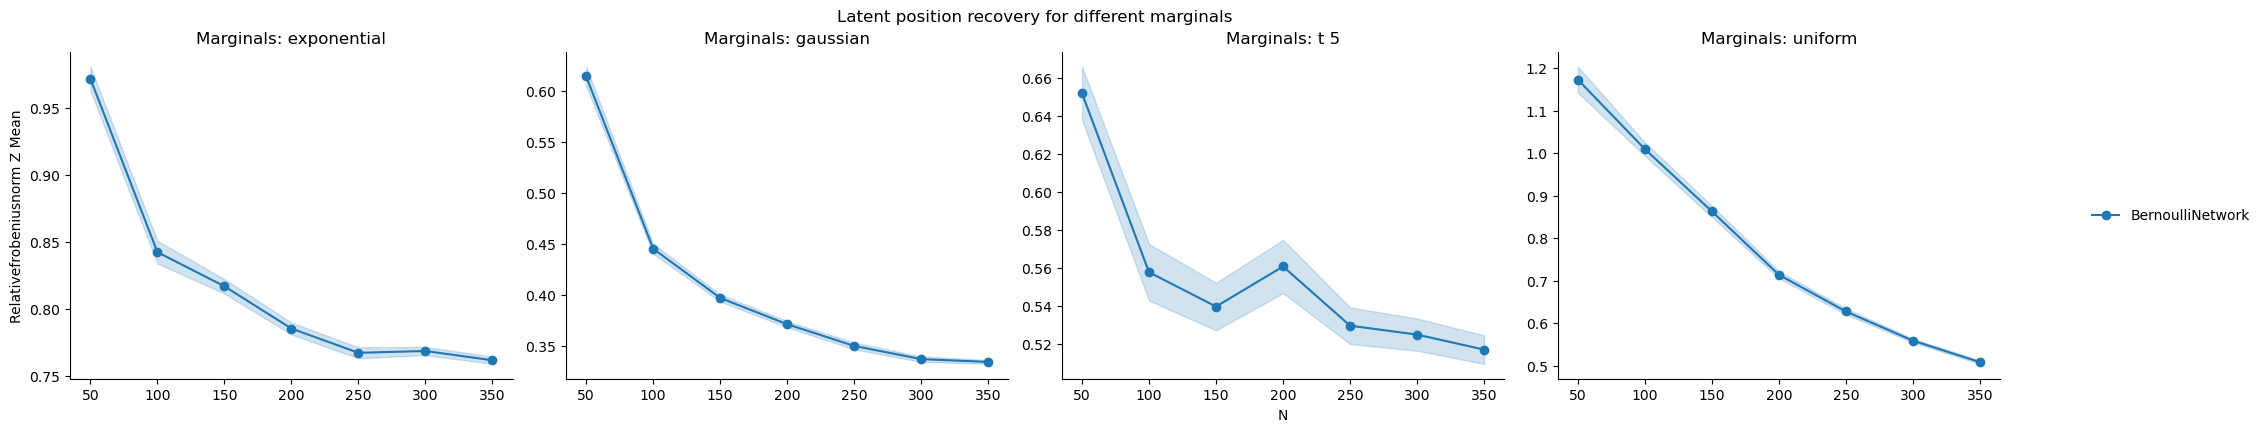

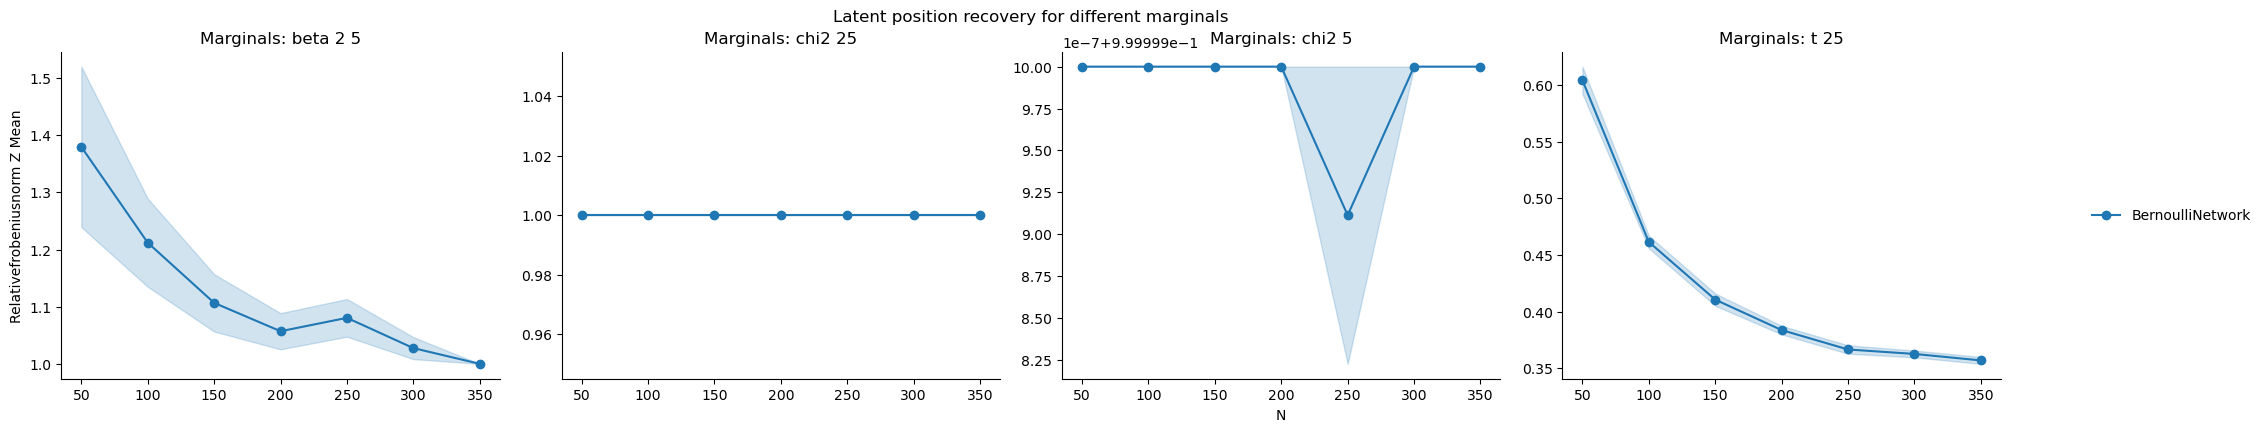

In [25]:
temp = agg_results[agg_results['dgp_name']=='BernoulliNetwork']
keep = ['gaussian', 't 5', 'exponential', 'uniform']

plot_grid(
    grouped_stats=temp[temp['marginals'].isin(keep)],
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="RelativeFrobeniusNorm_z_mean",
    factors=["dgp_name", "marginals"],
    height=4,
    se_bands="RelativeFrobeniusNorm_z_sem",
    share_x=True,
    share_y=False,
    title="Latent position recovery for different marginals",
)


plot_grid(
    grouped_stats=temp[~temp['marginals'].isin(keep)],
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="RelativeFrobeniusNorm_z_mean",
    factors=["dgp_name", "marginals"],
    height=4,
    se_bands="RelativeFrobeniusNorm_z_sem",
    share_x=True,
    share_y=False,
    title="Latent position recovery for different marginals",
)